# 01 — EDA (Owner A)

Exploratory data analysis for the deepfake datasets. Fill with:

- Dataset statistics (images per class / per generator)
- Class balance + generator identity plots
- Frequency-domain analysis (DCT / FFT magnitude, high-freq energy by class)
- Sample grids for real vs fake

**Rule:** this notebook saves figures/CSVs only under `results/comparison/` via Owner C, or its own scratch dir — never writes into another member's folders. Keep cell outputs cleared before committing.

In [1]:
from pathlib import Path
from collections import Counter

# Project root
PROJECT_ROOT = Path.cwd().parent

# Final experimental dataset directories
TRAIN_DIR = PROJECT_ROOT / "data" / "processed" / "train"
VAL_DIR = PROJECT_ROOT / "data" / "processed" / "val"
TEST_DIR = PROJECT_ROOT / "data" / "processed" / "test"
CROSS_GEN_DIR = PROJECT_ROOT / "data" / "cross_gen_test"

print("Project root:", PROJECT_ROOT)
print("Train directory:", TRAIN_DIR)
print("Validation directory:", VAL_DIR)
print("Test directory:", TEST_DIR)
print("Cross-generator directory:", CROSS_GEN_DIR)

# Check directories exist
for name, path in {
    "Train": TRAIN_DIR,
    "Validation": VAL_DIR,
    "Test": TEST_DIR,
    "Cross-generator": CROSS_GEN_DIR
}.items():
    print(f"{name}: {'OK' if path.exists() else 'NOT FOUND'}")

Project root: d:\Deep Fake\deepfake-detection
Train directory: d:\Deep Fake\deepfake-detection\data\processed\train
Validation directory: d:\Deep Fake\deepfake-detection\data\processed\val
Test directory: d:\Deep Fake\deepfake-detection\data\processed\test
Cross-generator directory: d:\Deep Fake\deepfake-detection\data\cross_gen_test
Train: OK
Validation: OK
Test: OK
Cross-generator: OK


In [3]:
# Count images in each split and class

def count_images_by_class(directory):
    counts = {}

    for class_name in ["real", "fake"]:
        class_dir = directory / class_name

        if class_dir.exists():
            image_count = sum(
                1 for file in class_dir.iterdir()
                if file.is_file()
            )
        else:
            image_count = 0

        counts[class_name] = image_count

    return counts


split_dirs = {
    "Train": TRAIN_DIR,
    "Validation": VAL_DIR,
    "Primary Test": TEST_DIR,
    "Cross-Generator Test": CROSS_GEN_DIR
}

dataset_counts = {}

for split_name, split_dir in split_dirs.items():
    dataset_counts[split_name] = count_images_by_class(split_dir)

dataset_counts

{'Train': {'real': 56700, 'fake': 49000},
 'Validation': {'real': 12150, 'fake': 10500},
 'Primary Test': {'real': 12150, 'fake': 10500},
 'Cross-Generator Test': {'real': 12150, 'fake': 1495}}

,real,fake,total,real_pct,fake_pct
Train,56700,49000,105700,53.64,46.36
Validation,12150,10500,22650,53.64,46.36
Primary Test,12150,10500,22650,53.64,46.36
Cross-Generator Test,12150,1495,13645,89.04,10.96


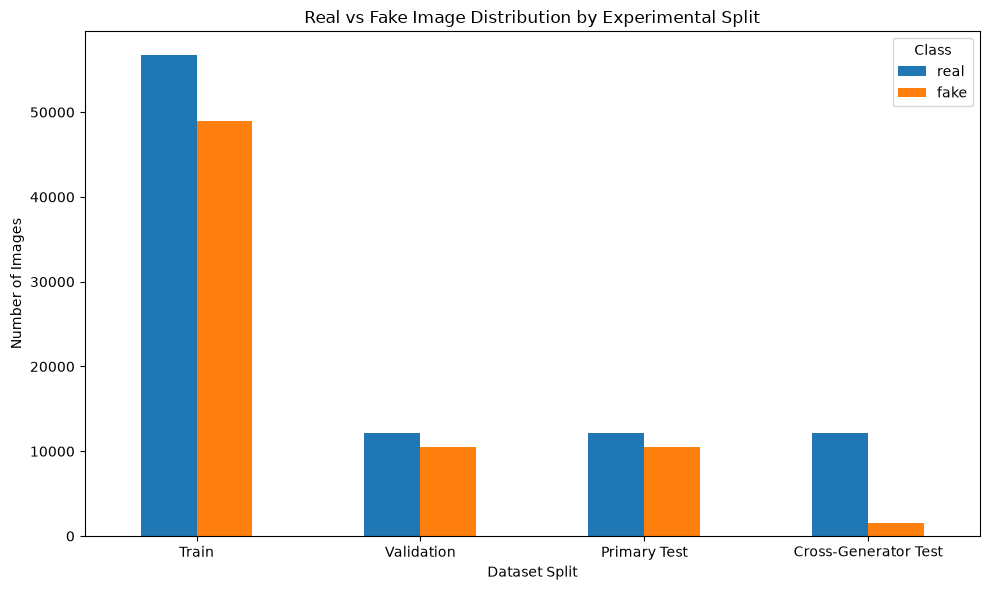

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert counts into a DataFrame
distribution_df = pd.DataFrame(dataset_counts).T

# Add total and percentage columns
distribution_df["total"] = distribution_df["real"] + distribution_df["fake"]
distribution_df["real_pct"] = (
    distribution_df["real"] / distribution_df["total"] * 100
)
distribution_df["fake_pct"] = (
    distribution_df["fake"] / distribution_df["total"] * 100
)

# Display distribution table
display(distribution_df.round(2))

# Class distribution plot
plot_df = distribution_df[["real", "fake"]]

ax = plot_df.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title("Real vs Fake Image Distribution by Experimental Split")
ax.set_xlabel("Dataset Split")
ax.set_ylabel("Number of Images")
ax.legend(title="Class")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [6]:
from pathlib import Path
import pandas as pd

RAW_DIR = PROJECT_ROOT / "data" / "raw"

print("Raw directory:", RAW_DIR)
print("Exists:", RAW_DIR.exists())

if RAW_DIR.exists():
    print("\nFiles in data/raw:")
    for file in RAW_DIR.iterdir():
        print(" -", file.name)

Raw directory: d:\Deep Fake\deepfake-detection\data\raw
Exists: True

Files in data/raw:
 - .gitkeep
 - archive
 - realvsfake-81k-by-wish.zip


In [7]:
# Load the original dataset metadata CSV files

ARCHIVE_DIR = RAW_DIR / "archive"

TRAIN_CSV = ARCHIVE_DIR / "train_labels.csv"
VAL_CSV = ARCHIVE_DIR / "val_labels.csv"
TEST_CSV = ARCHIVE_DIR / "test_labels.csv"

train_meta = pd.read_csv(TRAIN_CSV)
val_meta = pd.read_csv(VAL_CSV)
test_meta = pd.read_csv(TEST_CSV)

print("Train metadata:", train_meta.shape)
print("Validation metadata:", val_meta.shape)
print("Test metadata:", test_meta.shape)

print("\nColumns:")
print(train_meta.columns.tolist())

print("\nTrain source distribution:")
display(train_meta["source"].value_counts())

print("\nValidation source distribution:")
display(val_meta["source"].value_counts())

print("\nTest source distribution:")
display(test_meta["source"].value_counts())

Train metadata: (113381, 3)
Validation metadata: (24296, 3)
Test metadata: (24295, 3)

Columns:
['filepath', 'label', 'source']

Train source distribution:


source
StyleGAn           49000
CelebA             28350
FFHQ               28350
StableDiffusion     6980
AiGenImage           701
Name: count, dtype: int64


Validation source distribution:


source
StyleGAn           10500
FFHQ                6075
CelebA              6075
StableDiffusion     1496
AiGenImage           150
Name: count, dtype: int64


Test source distribution:


source
StyleGAn           10500
FFHQ                6075
CelebA              6075
StableDiffusion     1495
AiGenImage           150
Name: count, dtype: int64

In [8]:
# Analyze source × class distribution

def source_class_distribution(df):
    table = pd.crosstab(
        df["source"],
        df["label"]
    )

    # Rename labels for readability
    table = table.rename(
        columns={
            0: "Real",
            1: "Fake"
        }
    )

    return table


train_source_class = source_class_distribution(train_meta)
val_source_class = source_class_distribution(val_meta)
test_source_class = source_class_distribution(test_meta)

print("TRAIN — Source × Class")
display(train_source_class)

print("VALIDATION — Source × Class")
display(val_source_class)

print("TEST — Source × Class")
display(test_source_class)

TRAIN — Source × Class


label,Real,Fake
source,,
AiGenImage,0,701
CelebA,28350,0
FFHQ,28350,0
StableDiffusion,0,6980
StyleGAn,0,49000


VALIDATION — Source × Class


label,Real,Fake
source,,
AiGenImage,0,150
CelebA,6075,0
FFHQ,6075,0
StableDiffusion,0,1496
StyleGAn,0,10500


TEST — Source × Class


label,Real,Fake
source,,
AiGenImage,0,150
CelebA,6075,0
FFHQ,6075,0
StableDiffusion,0,1495
StyleGAn,0,10500


source,AiGenImage,CelebA,FFHQ,StableDiffusion,StyleGAn
split,,,,,
Test,150,6075,6075,1495,10500
Train,701,28350,28350,6980,49000
Validation,150,6075,6075,1496,10500


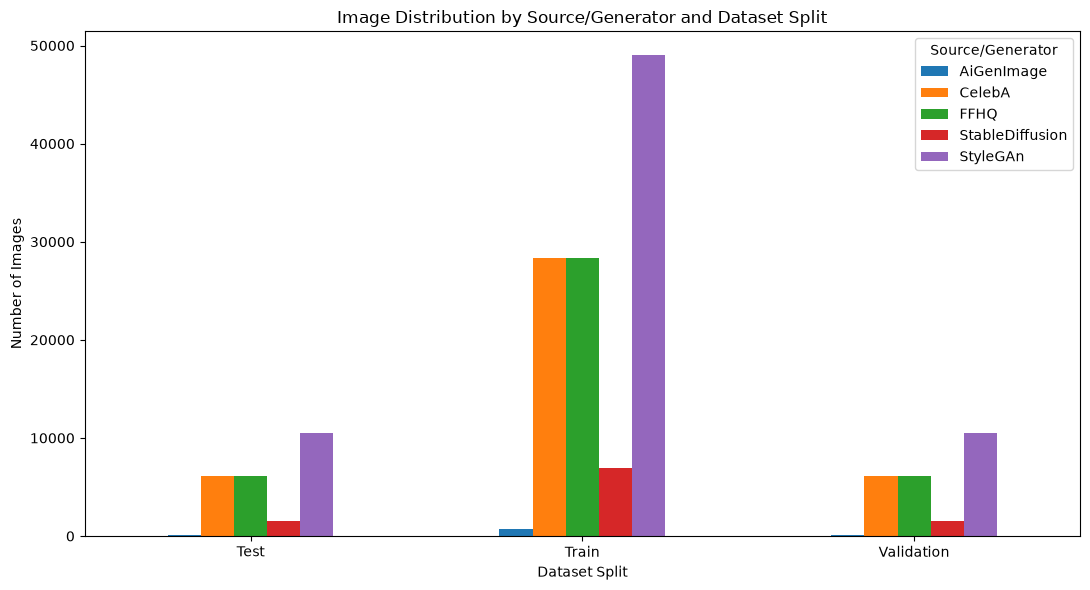

In [9]:
# Visualize generator/source distribution in the original dataset

source_counts = pd.concat(
    [
        train_meta.assign(split="Train"),
        val_meta.assign(split="Validation"),
        test_meta.assign(split="Test")
    ],
    ignore_index=True
)

source_split_counts = (
    source_counts
    .groupby(["split", "source"])
    .size()
    .unstack(fill_value=0)
)

display(source_split_counts)

ax = source_split_counts.plot(
    kind="bar",
    figsize=(11, 6)
)

ax.set_title("Image Distribution by Source/Generator and Dataset Split")
ax.set_xlabel("Dataset Split")
ax.set_ylabel("Number of Images")
ax.legend(title="Source/Generator")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

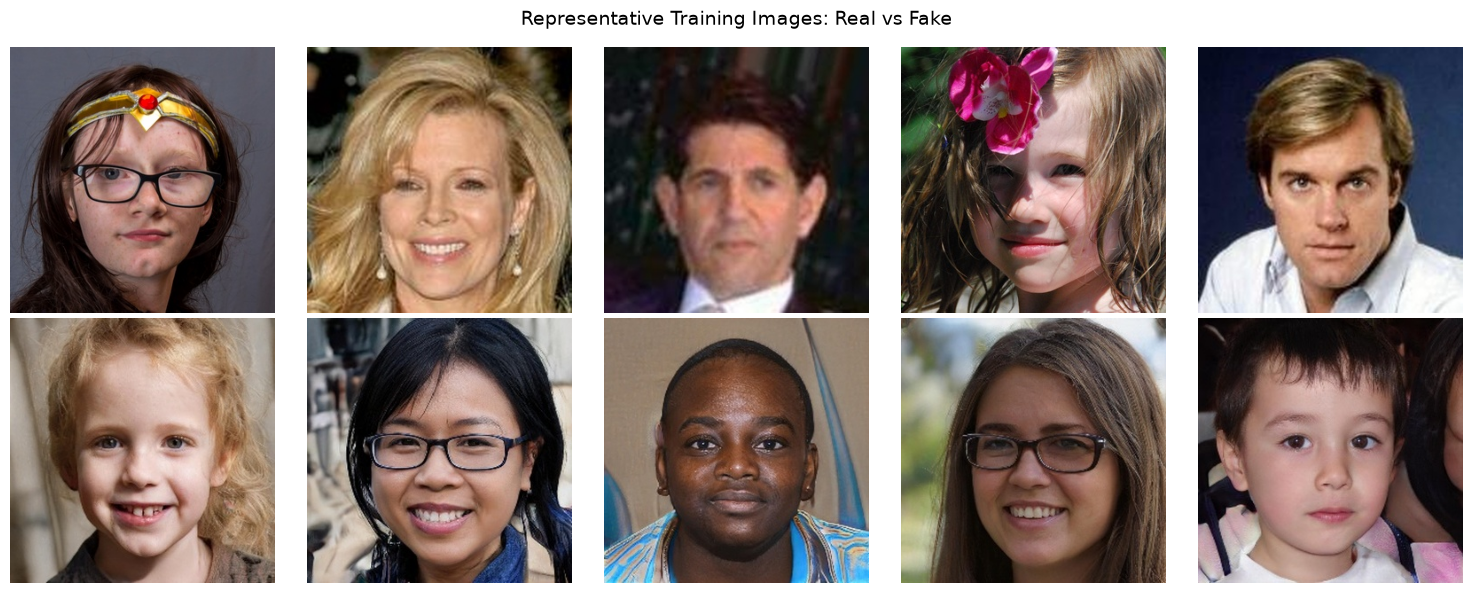

In [10]:
# Display representative images from the final training dataset

import random
from PIL import Image
import matplotlib.pyplot as plt

random.seed(42)

def get_image_files(directory, n=5):
    files = [
        file for file in directory.iterdir()
        if file.is_file()
    ]
    return random.sample(files, min(n, len(files)))


real_samples = get_image_files(TRAIN_DIR / "real", 5)
fake_samples = get_image_files(TRAIN_DIR / "fake", 5)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Real images
for ax, image_path in zip(axes[0], real_samples):
    image = Image.open(image_path).convert("RGB")
    ax.imshow(image)
    ax.axis("off")

axes[0, 0].set_ylabel("REAL", fontsize=12)

# Fake images
for ax, image_path in zip(axes[1], fake_samples):
    image = Image.open(image_path).convert("RGB")
    ax.imshow(image)
    ax.axis("off")

axes[1, 0].set_ylabel("FAKE", fontsize=12)

fig.suptitle("Representative Training Images: Real vs Fake", fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
# Inspect image dimensions and formats in representative samples

from collections import Counter

sample_paths = real_samples + fake_samples

image_sizes = []
image_formats = []
image_modes = []

for image_path in sample_paths:
    with Image.open(image_path) as image:
        image_sizes.append(image.size)
        image_formats.append(image.format)
        image_modes.append(image.mode)

print("Sample image sizes:")
print(Counter(image_sizes))

print("\nImage formats:")
print(Counter(image_formats))

print("\nImage modes:")
print(Counter(image_modes))

Sample image sizes:
Counter({(299, 299): 10})

Image formats:
Counter({'JPEG': 10})

Image modes:
Counter({'RGB': 10})


In [12]:
# Check for unreadable/corrupted images in the final experimental dataset

from PIL import Image

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def check_image_files(directory):
    image_files = [
        path
        for path in directory.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    ]

    corrupted_files = []

    for image_path in image_files:
        try:
            with Image.open(image_path) as image:
                image.verify()
        except Exception:
            corrupted_files.append(image_path)

    return len(image_files), corrupted_files


quality_dirs = {
    "Train": TRAIN_DIR,
    "Validation": VAL_DIR,
    "Primary Test": TEST_DIR,
    "Cross-Generator Test": CROSS_GEN_DIR
}

quality_results = {}

for split_name, split_dir in quality_dirs.items():
    total_files, corrupted_files = check_image_files(split_dir)

    quality_results[split_name] = {
        "total_images_checked": total_files,
        "corrupted_images": len(corrupted_files)
    }

display(pd.DataFrame(quality_results).T)

,total_images_checked,corrupted_images
Train,105700,0
Validation,22650,0
Primary Test,22650,0
Cross-Generator Test,13645,0


In [13]:
# Check for exact filepath overlap between experimental splits

def get_relative_image_paths(directory):
    return {
        path.relative_to(directory).as_posix()
        for path in directory.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    }


train_paths = get_relative_image_paths(TRAIN_DIR)
val_paths = get_relative_image_paths(VAL_DIR)
test_paths = get_relative_image_paths(TEST_DIR)
cross_paths = get_relative_image_paths(CROSS_GEN_DIR)

overlap_results = {
    "Train ∩ Validation": len(train_paths & val_paths),
    "Train ∩ Primary Test": len(train_paths & test_paths),
    "Validation ∩ Primary Test": len(val_paths & test_paths),
    "Train ∩ Cross-Generator": len(train_paths & cross_paths),
    "Validation ∩ Cross-Generator": len(val_paths & cross_paths),
}

display(pd.Series(overlap_results, name="Overlapping Files"))

Train ∩ Validation              0
Train ∩ Primary Test            0
Validation ∩ Primary Test       0
Train ∩ Cross-Generator         0
Validation ∩ Cross-Generator    0
Name: Overlapping Files, dtype: int64

## Preprocessing Pipeline

The final experimental pipeline applies deterministic preprocessing to all images and training-only augmentation to improve robustness.

### Training Set

- Resize images to 224 × 224 pixels.
- Random horizontal flip with probability 0.5.
- Random rotation up to ±10°.
- Color jitter with brightness, contrast, and saturation changes of 0.2.
- Random Gaussian blur with probability 0.2.
- Convert images to tensors.
- Normalize using ImageNet mean and standard deviation.

### Validation, Primary Test and Cross-Generator Test

- Resize images to 224 × 224 pixels.
- Convert images to tensors.
- Apply ImageNet normalization.
- No random augmentation is applied during evaluation.

### Label Convention

The project uses a fixed binary label convention:

- Real → 0
- Fake → 1

This convention is explicitly enforced in the shared data-loading pipeline to maintain consistent labels across all models and evaluation metrics.